# RedKite Aerospace - Hand-Signal Gesture Classification for Autonomous Medical Delivery

## 1. Background

RedKite Aerospace is pursuing a contract with a regional emergency-services provider to deliver
time-critical medical supplies (e.g. blood products) via drone to sites that are difficult for
ground vehicles to reach quickly. The client's Request for Proposal (RFP) mandates that, on
arrival at a delivery site, the aircraft must be able to interpret marshalling-style hand
signals from the person receiving the package — with no radio link and no companion app. The
receiver may direct the drone left or right, ask it to hold, signal that the landing zone is
clear or unsafe, or wave the aircraft off entirely.

RedKite's airframe already satisfies every hardware requirement in the RFP. This gesture-reading
capability is the one missing piece, and a live demonstration is scheduled in three weeks. If the
aircraft can correctly read a client staff member's gestures on the day, the contract is
winnable; if not, the opportunity is lost.

## 2. Task

An onboard segmenter (provided, out of scope for this notebook) observes the receiver and splits
the video stream into discrete gesture **instances**. Each instance is delivered to the
classifier as exactly **5 frames**.

**Goal:** given one pre-segmented instance (5 frames), classify it into one of 13 gesture
classes:

`AllClear`, `HaveCommand`, `Hover`, `Land`, `LandingDirection`, `MoveAhead`, `MoveDownward`,
`MoveToLeft`, `MoveToRight`, `MoveUpward`, `NotClear`, `SlowDown`, `WaveOff`

This notebook covers **classification only** - no person detection, no video segmentation, and
no live-stream handling. One instance in, one class out.

## 3. Constraints and Operating Context

- **Timeline:** three weeks to a live demo - favours pragmatic, well-justified choices over
  exhaustive experimentation.
- **Data:** a single afternoon of colleagues (non-professional signallers) performing the
  gestures on camera. Small sample size, limited signaller diversity, and likely class imbalance
  are expected and will shape both modelling choices and how much the results can be trusted.
- **Deliverable expectation:** the executives are not just looking for a working model - they
  want sound engineering judgement and an honest account of how far the result generalises
  beyond this dataset (e.g. to a different signaller, lighting, or background on demo day).

## 4. Notebook Structure

1. Data loading and exploration
2. Preprocessing and augmentation strategy
3. Model design and training
4. Evaluation (including class-level performance and error analysis)
5. Discussion of limitations and confidence in real-world (demo-day) performance

## 0. Environment and reproducibility

A fixed seed is set for Python, NumPy and PyTorch, cuDNN is placed in deterministic mode, and DataLoader workers are seeded from a generator derived from the same root seed. Determinism costs a little throughput on cuDNN, which is an acceptable trade for a submission that must reproduce under *Restart & Run All*.

`CONFIG` collects every knob in one place so that no magic number is buried in a function body.

In [1]:
# Loading necessary libraries
import os, sys, math, json, time, random, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision.io import read_image, ImageReadMode
import torchvision.transforms.functional as TF
from torchvision.models import mobilenet_v3_small, MobileNet_V3_Small_Weights
from sklearn.model_selection import GroupKFold
from sklearn.metrics import (f1_score, accuracy_score, confusion_matrix,
                             classification_report, balanced_accuracy_score)

In [2]:
warnings.filterwarnings("ignore", category=UserWarning)

SEED = 42

def seed_everything(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_everything()

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

CONFIG = dict(
    dataset_root   = "data_resized",
    img_size       = 224,              # ImageNet-native resolution for the pretrained stem
    batch_size     = 16,
    epochs_frozen  = 3,                # head warm-up with trunk frozen
    epochs_ft      = 17,               # full fine-tune with discriminative LRs
    lr_head        = 1e-3,
    lr_trunk       = 1e-4,
    weight_decay   = 1e-4,
    label_smooth   = 0.1,
    patience       = 6,                # early stop on validation macro-F1
    num_workers    = 2,
    n_test_frac    = 0.25,             # fraction of SUBJECTS held out as the final test set
    max_cv_folds   = 5,
    ablation_folds = 3,                # fewer folds for the ablation grid, to bound runtime
)

print("torch", torch.__version__, "| device:", DEVICE)
if DEVICE.type == "cuda":
    print("gpu:", torch.cuda.get_device_name(0))
print("seed:", SEED)

torch 2.10.0+cu128 | device: cuda
gpu: Tesla T4
seed: 42


## 1. Dataset inventory and exploratory analysis

Before choosing an architecture we need three facts from the data, because each one closes off a design option:

1. **How many distinct people are there, and does every person perform every class?** This determines whether subject-wise cross-validation is even feasible, and how many folds we can afford.
2. **Is every instance exactly 5 frames?** The model architecture hard-codes a 5-frame input; any deviation must be found now rather than as a shape error mid-training.
3. **How much motion is actually present across the 5 frames?** If consecutive frames are near-identical, temporal fusion buys nothing and a single-frame model would be the honest choice. If motion energy is substantial and class-dependent, temporal fusion is justified - and we should be able to see that difference in a plot before we ever train.

In [3]:
DATASET_ROOT = Path(CONFIG["dataset_root"])

ACTIONS = [
    "AllClear", "HaveCommand", "Hover", "Land", "LandingDirection",
    "MoveAhead", "MoveDownward", "MoveToLeft", "MoveToRight",
    "MoveUpward", "NotClear", "SlowDown", "WaveOff",
]
N_CLASSES = len(ACTIONS)
ACTION_TO_IDX = {a: i for i, a in enumerate(ACTIONS)}

# Safety-critical abort commands. A miss here is an aircraft approaching an unsafe zone.
CRITICAL = ["WaveOff", "NotClear"]

records = []
for action in ACTIONS:
    action_dir = DATASET_ROOT / action
    if not action_dir.exists():
        print(f"Missing folder for action: {action}")
        continue
    for subject_dir in sorted(action_dir.iterdir()):
        if not subject_dir.is_dir():
            continue
        for instance_dir in sorted(subject_dir.iterdir()):
            if not instance_dir.is_dir():
                continue
            frame_paths = sorted(instance_dir.glob("*.png"))
            records.append(dict(
                action      = action,
                subject     = subject_dir.name,
                instance    = instance_dir.name,
                n_frames    = len(frame_paths),
                frame_paths = [str(p) for p in frame_paths],
            ))

df = pd.DataFrame(records)
df["y"] = df["action"].map(ACTION_TO_IDX)
print(f"Total instances found: {len(df)}")
df.head()

Total instances found: 1059


,action,subject,instance,n_frames,frame_paths,y
0,AllClear,S1,Instance1,5,[data_resized/AllClear/S1/Instance1/S1_allClea...,0
1,AllClear,S1,Instance2,5,[data_resized/AllClear/S1/Instance2/S1_allClea...,0
2,AllClear,S1,Instance3,5,[data_resized/AllClear/S1/Instance3/S1_allClea...,0
3,AllClear,S1,Instance4,5,[data_resized/AllClear/S1/Instance4/S1_allClea...,0
4,AllClear,S1,Instance5,5,[data_resized/AllClear/S1/Instance5/S1_allClea...,0


In [4]:
# Integrity check: the architecture assumes exactly 5 frames per instance
bad = df[df["n_frames"] != 5]
if len(bad):
    print(f"{len(bad)} instance(s) do NOT have 5 frames -- dropping them so the tensor shape is guaranteed:")
    display(bad[["action", "subject", "instance", "n_frames"]])
    df = df[df["n_frames"] == 5].reset_index(drop=True)
else:
    print("All instances have exactly 5 frames.")

print("\nInstances per action:")
print(df["action"].value_counts().reindex(ACTIONS))

SUBJECTS = sorted(df["subject"].unique())
print(f"\n{len(SUBJECTS)} subjects present: {SUBJECTS}")

ct = pd.crosstab(df["subject"], df["action"]).reindex(columns=ACTIONS, fill_value=0)
print("\nInstances per subject per action:")
display(ct)

empty_cells = int((ct == 0).sum().sum())
print(f"\n(subject, class) combinations with zero instances: {empty_cells}")
if empty_cells:
    print("  -> Some held-out folds will contain classes the model never sees for that person.")
    print("  -> All metrics below therefore pass labels=range(13) and zero_division=0 explicitly.")

All instances have exactly 5 frames.

Instances per action:
action
AllClear             87
HaveCommand          85
Hover                82
Land                122
LandingDirection     48
MoveAhead            99
MoveDownward         46
MoveToLeft           95
MoveToRight          95
MoveUpward           62
NotClear             86
SlowDown             93
WaveOff              59
Name: count, dtype: int64

11 subjects present: ['S1', 'S11', 'S12', 'S13', 'S14', 'S15', 'S3', 'S4', 'S5', 'S6', 'S9']

Instances per subject per action:


action,AllClear,HaveCommand,Hover,Land,LandingDirection,MoveAhead,MoveDownward,MoveToLeft,MoveToRight,MoveUpward,NotClear,SlowDown,WaveOff
subject,,,,,,,,,,,,,
S1,8,9,9,17,7,10,8,9,9,10,5,9,9
S11,9,7,9,19,9,8,5,9,8,9,9,9,9
S12,8,7,11,18,8,10,8,8,9,9,7,10,12
S13,4,9,11,18,8,9,5,9,8,10,9,7,8
S14,10,8,0,0,0,8,0,9,8,0,10,11,0
S15,7,9,0,0,0,10,0,9,9,0,9,10,0
S3,9,10,0,0,0,10,0,10,9,0,10,9,0
S4,7,7,13,17,7,6,7,7,10,8,6,6,7
S5,6,5,16,17,4,8,6,7,6,7,6,5,6



(subject, class) combinations with zero instances: 24
  -> Some held-out folds will contain classes the model never sees for that person.
  -> All metrics below therefore pass labels=range(13) and zero_division=0 explicitly.


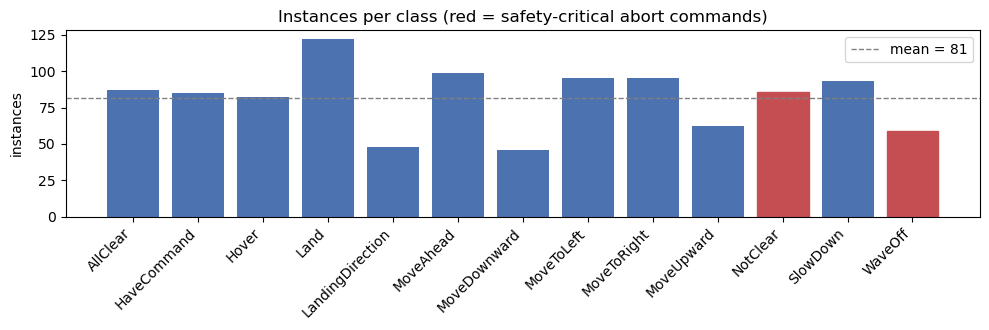

Imbalance ratio (max/min) = 2.65
Decision: macro-F1 is the headline metric regardless of this ratio, because every gesture
carries equal operational weight -- a rare command is not a less important command.


In [5]:
# Class balance figure 
counts = df["action"].value_counts().reindex(ACTIONS)
fig, ax = plt.subplots(figsize=(10, 3.4))
bars = ax.bar(range(N_CLASSES), counts.values, color="#4C72B0")
for a in CRITICAL:
    bars[ACTION_TO_IDX[a]].set_color("#C44E52")
ax.set_xticks(range(N_CLASSES)); ax.set_xticklabels(ACTIONS, rotation=45, ha="right")
ax.set_ylabel("instances"); ax.set_title("Instances per class (red = safety-critical abort commands)")
ax.axhline(counts.mean(), ls="--", c="grey", lw=1, label=f"mean = {counts.mean():.0f}")
ax.legend(); plt.tight_layout(); plt.show()

imb = counts.max() / max(counts.min(), 1)
print(f"Imbalance ratio (max/min) = {imb:.2f}")
print("Decision: macro-F1 is the headline metric regardless of this ratio, because every gesture")
print("carries equal operational weight -- a rare command is not a less important command.")

In [6]:
# Native image resolution 
sample_paths = df["frame_paths"].explode().sample(min(60, len(df) * 5), random_state=SEED)
shapes = [tuple(read_image(p, ImageReadMode.RGB).shape[1:]) for p in sample_paths]
shape_counts = pd.Series(shapes).value_counts()
print("Native (H, W) of sampled frames:")
print(shape_counts)
print(f"\nWorking resolution: {CONFIG['img_size']}x{CONFIG['img_size']}")
print("Rationale: MobileNetV3 was pretrained at 224px; feeding the stem its native scale keeps the")
print("pretrained filters in the spatial-frequency regime they were fitted for. If the source frames")
print("are much smaller than 224 the upsample is wasted compute -- see the note below.")
native_h = shape_counts.index[0][0]
if native_h < CONFIG["img_size"]:
    print(f"\nNOTE: source frames are {native_h}px tall, smaller than {CONFIG['img_size']}.")
    print("Consider setting CONFIG['img_size'] to 160 and re-running: less compute, no information lost.")

Native (H, W) of sampled frames:
(512, 512)    60
Name: count, dtype: int64

Working resolution: 224x224
Rationale: MobileNetV3 was pretrained at 224px; feeding the stem its native scale keeps the
pretrained filters in the spatial-frequency regime they were fitted for. If the source frames
are much smaller than 224 the upsample is wasted compute -- see the note below.


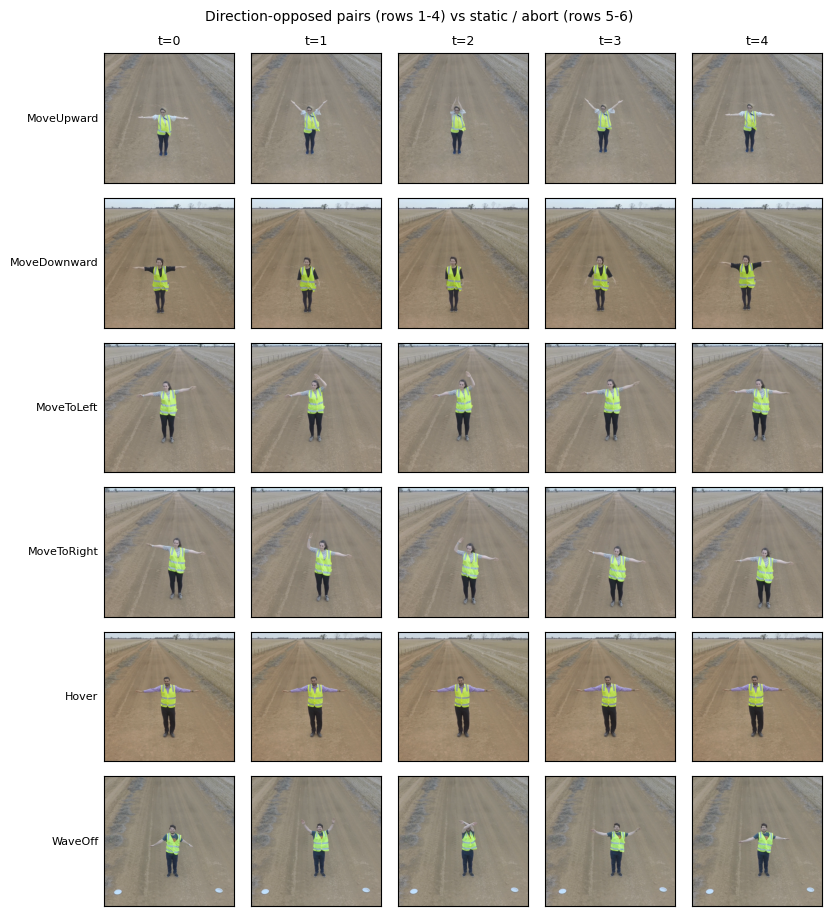

In [16]:
# Frame montage: the classes that drive the fusion and augmentation decisions 
seed_everything()
FOCUS = ["MoveUpward", "MoveDownward", "MoveToLeft", "MoveToRight", "Hover", "WaveOff"]
FOCUS = [a for a in FOCUS if (df.action == a).any()]

fig, axes = plt.subplots(len(FOCUS), 5, figsize=(8.5, 1.55 * len(FOCUS)))
for r, action in enumerate(FOCUS):
    row = df[df.action == action].sample(1, random_state=SEED).iloc[0]
    for c, p in enumerate(row.frame_paths):
        axes[r, c].imshow(read_image(p, ImageReadMode.RGB).permute(1, 2, 0).numpy())
        axes[r, c].set_xticks([]); axes[r, c].set_yticks([])
        if r == 0:
            axes[r, c].set_title(f"t={c}", fontsize=9)
    axes[r, 0].set_ylabel(action, fontsize=8, rotation=0, ha="right", va="center")
fig.suptitle("Direction-opposed pairs (rows 1-4) vs static / abort (rows 5-6)", fontsize=10)
plt.tight_layout(); plt.show()

### Reading the montage

Three findings, each of which determines a decision below.

**1. The gestures are oscillatory, not directional.** `MoveUpward` runs rest -> arms-above-head -> rest; `MoveDownward` runs rest -> arms-below-shoulder -> rest. Neither traverses a trajectory that reverses into the other. The direction-opposed pairs are separated by **which extreme pose is reached** - which is spatial, not temporal. This corrects a natural assumption: these classes are *not* approximate time-reversals of one another.

**2. A single frame is ambiguous with `Hover`.** At t=0 and t=4, `MoveUpward`, `MoveDownward`, `MoveToLeft` and `WaveOff` all sit in the same arms-out horizontal rest pose - which is exactly the pose `Hover` holds for its entire duration. A classifier given one frame sampled at the wrong phase of the oscillation cannot distinguish four distinct commands from a hold instruction.

**This is the justification for using all five frames: pose coverage across the oscillation cycle, not motion direction.** Five frames guarantee that at least one distinctive extreme is observed regardless of where the segmenter happened to cut.

**3. `MoveToLeft` and `MoveToRight` are near-exact horizontal mirrors of each other.** Flipping one produces a visually valid instance of the other while leaving the label untouched. This is the direct empirical evidence for the no-flip rule in §3.

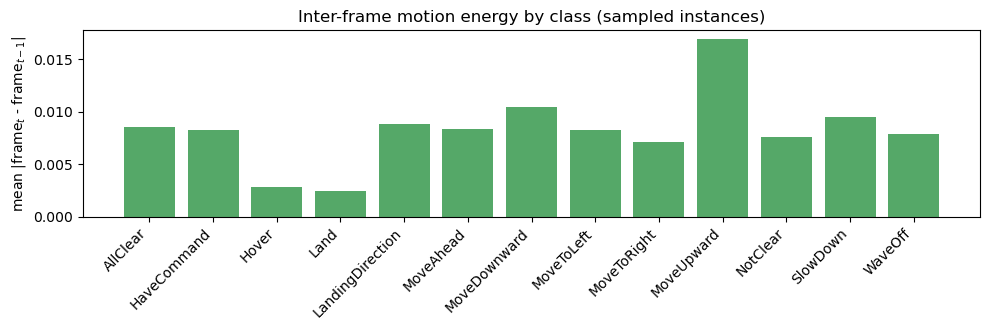

Overall mean motion energy: 0.0082
If this is far above zero and varies by class, consecutive frames are NOT redundant and a
temporal-fusion model has real information to exploit. This is the pre-registered justification
for the 5-frame architecture; the ablation in section 6 tests whether the model actually uses it.


In [10]:
# Motion energy: mean absolute inter-frame difference, per class 
seed_everything()
parts = []
for a in ACTIONS:
    g_ = df[df.action == a]
    if len(g_):
        parts.append(g_.sample(min(len(g_), 12), random_state=SEED))
sub = pd.concat(parts, ignore_index=True)

def motion_energy(paths, size=64):
    clip = torch.stack([read_image(p, ImageReadMode.RGB) for p in paths]).float() / 255.
    clip = TF.resize(clip, [size, size], antialias=True)
    return (clip[1:] - clip[:-1]).abs().mean().item()

sub = sub.copy()
sub["motion"] = [motion_energy(p) for p in sub.frame_paths]
order = sub.groupby("action")["motion"].mean().reindex(ACTIONS)

fig, ax = plt.subplots(figsize=(10, 3.4))
ax.bar(range(N_CLASSES), order.values, color="#55A868")
ax.set_xticks(range(N_CLASSES)); ax.set_xticklabels(ACTIONS, rotation=45, ha="right")
ax.set_ylabel("mean |frame$_t$ - frame$_{t-1}$|")
ax.set_title("Inter-frame motion energy by class (sampled instances)")
plt.tight_layout(); plt.show()

print(f"Overall mean motion energy: {sub.motion.mean():.4f}")
print("If this is far above zero and varies by class, consecutive frames are NOT redundant and a")
print("temporal-fusion model has real information to exploit. This is the pre-registered justification")
print("for the 5-frame architecture; the ablation in section 6 tests whether the model actually uses it.")

### Background confound check

The montage shows different ground surfaces behind different classes. That is a leakage risk worth testing *before* training rather than diagnosing afterwards from a suspiciously high score.

The distinction that matters:

- **Background varies across subjects within a class** -> scenery tracks the person or the recording session, and subject-wise splitting (§2) already controls for it. This is the benign case.
- **Background is constant within a class but differs between classes** -> the label is recoverable from scenery alone, the model has a shortcut that will not exist on demo day, and the held-out score is an artefact.

If the second case holds, Grad-CAM in §10 stops being a nice-to-have and becomes a pass/fail gate on the whole result.

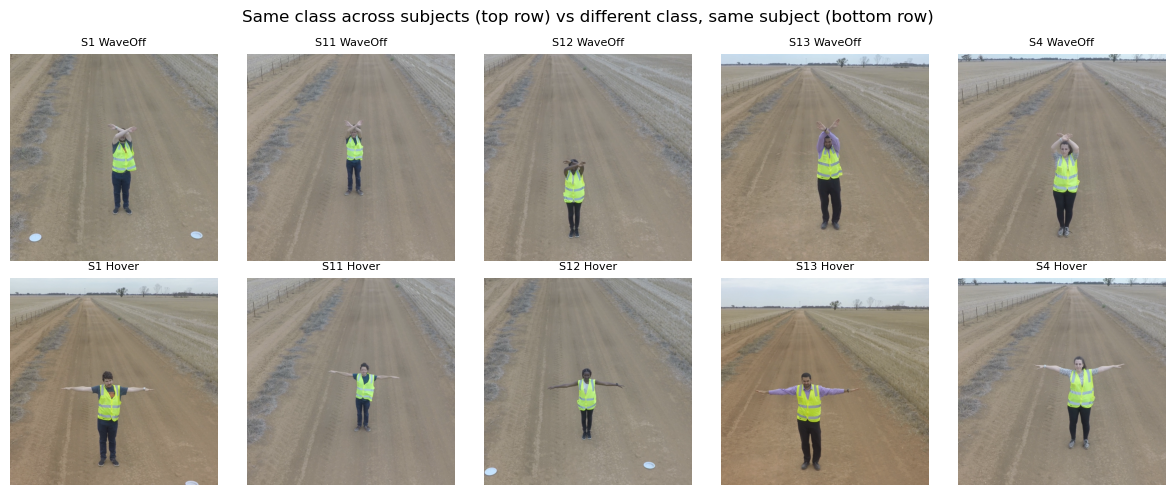

In [18]:
# Confound check: does BACKGROUND vary within a class, or is it class-specific?
seed_everything()
CHECK_CLASS = "WaveOff"
sub_ids = sorted(df[df.action == CHECK_CLASS].subject.unique())[:5]

fig, axes = plt.subplots(2, max(len(sub_ids), 1), figsize=(2.4 * max(len(sub_ids), 1), 5))
axes = np.atleast_2d(axes)
for c, s_ in enumerate(sub_ids):
    r1 = df[(df.action == CHECK_CLASS) & (df.subject == s_)].iloc[0]
    axes[0, c].imshow(read_image(r1.frame_paths[2], ImageReadMode.RGB).permute(1, 2, 0).numpy())
    axes[0, c].set_title(f"{s_} {CHECK_CLASS}", fontsize=8)
    r2 = df[(df.action == "Hover") & (df.subject == s_)]
    if len(r2):
        axes[1, c].imshow(read_image(r2.iloc[0].frame_paths[2], ImageReadMode.RGB).permute(1, 2, 0).numpy())
        axes[1, c].set_title(f"{s_} Hover", fontsize=8)
    axes[0, c].axis("off"); axes[1, c].axis("off")
fig.suptitle("Same class across subjects (top row) vs different class, same subject (bottom row)")
plt.tight_layout(); plt.show()

## 2. Evaluation framework

### 2.1 Why the split is by *person*, not by instance

The deployment condition is fixed and known: **an unseen individual signals to the aircraft.** A random instance-level split would place the same colleague — same height, same build, same clothing, same idiosyncratic way of throwing an arm — on both sides of the partition. The model can then identify the *person* and recall what that person's gestures look like, and the reported score measures memorisation rather than generalisation. This is the same clip-level leakage failure mode that produces the familiar pattern of near-perfect in-domain scores collapsing on out-of-domain data.

We therefore use a **grouped** protocol with `subject` as the group, at two levels:

- **A locked held-out test set of subjects.** Chosen once, from the seed, before any modelling. Touched exactly once, in §9. Nothing - not architecture, not hyperparameters, not the abstention threshold - is selected using it.
- **Grouped k-fold cross-validation on the remaining development subjects.** Every architectural and hyperparameter decision in §6 and §7 is made on the CV mean. Because the number of people is small, a single validation subject is extremely noisy; the fold-to-fold **standard deviation** is reported alongside every mean and is treated as the real uncertainty on any comparison. A difference smaller than that spread is not a result.

With very few subjects this reduces to leave-one-subject-out, which is the correct limit case.

### 2.2 Why these metrics

| Metric | Role | Justification |
|---|---|---|
| **Macro-F1** | headline, model selection | Averages per-class F1 with equal weight. Every gesture is an operational command; a rarely-recorded command is not a less important one. Micro-accuracy would let the model coast on whichever classes happen to be over-represented. |
| **Balanced accuracy** | secondary | Mean per-class recall. Reported because it is the quantity a client naturally asks about ("how often does it read me correctly?"). |
| **Per-class recall** | diagnostic | Locates *which* commands fail, which a single scalar hides. |
| **Abort recall** (`WaveOff`, `NotClear`) | safety gate | Reported and argued separately. Confusing `MoveToLeft` with `MoveToRight` yields a wrong but recoverable manoeuvre. Missing an abort means continuing an approach into a zone the receiver has declared unsafe, with blood products aboard. These errors are not commensurable and must not be averaged into one number. |
| **Fold / subject spread** | honesty | The per-subject scatter is our actual confidence interval for demo day. |

Selection is on validation macro-F1 with early stopping; the test set never participates.

In [19]:
seed_everything()

n_test = max(1, int(round(len(SUBJECTS) * CONFIG["n_test_frac"])))
rng = np.random.RandomState(SEED)
TEST_SUBJECTS = sorted(rng.choice(SUBJECTS, size=n_test, replace=False).tolist())
DEV_SUBJECTS  = [s for s in SUBJECTS if s not in TEST_SUBJECTS]

dev_df  = df[df.subject.isin(DEV_SUBJECTS)].reset_index(drop=True)
test_df = df[df.subject.isin(TEST_SUBJECTS)].reset_index(drop=True)

N_FOLDS = min(CONFIG["max_cv_folds"], len(DEV_SUBJECTS))
gkf = GroupKFold(n_splits=N_FOLDS)
FOLDS = list(gkf.split(dev_df, dev_df.y, groups=dev_df.subject))

print(f"Development subjects ({len(DEV_SUBJECTS)}): {DEV_SUBJECTS}   -> {len(dev_df)} instances")
print(f"Held-out TEST subjects ({len(TEST_SUBJECTS)}): {TEST_SUBJECTS}   -> {len(test_df)} instances")
print(f"\nGroupKFold with n_splits={N_FOLDS} on the development subjects:")
for k, (tr, va) in enumerate(FOLDS):
    va_subj = sorted(dev_df.iloc[va].subject.unique())
    print(f"  fold {k}: train={len(tr):4d} inst | val={len(va):3d} inst | val subjects={va_subj}")

assert set(dev_df.subject) & set(test_df.subject) == set(), "subject leakage between dev and test"
print("\nLeakage assertion passed: no subject appears in both dev and test.")

Development subjects (8): ['S11', 'S12', 'S13', 'S14', 'S3', 'S4', 'S5', 'S9']   -> 763 instances
Held-out TEST subjects (3): ['S1', 'S15', 'S6']   -> 296 instances

GroupKFold with n_splits=5 on the development subjects:
  fold 0: train= 638 inst | val=125 inst | val subjects=['S12']
  fold 1: train= 644 inst | val=119 inst | val subjects=['S11']
  fold 2: train= 584 inst | val=179 inst | val subjects=['S13', 'S14']
  fold 3: train= 589 inst | val=174 inst | val subjects=['S4', 'S9']
  fold 4: train= 597 inst | val=166 inst | val subjects=['S3', 'S5']

Leakage assertion passed: no subject appears in both dev and test.


In [20]:
# Metric helpers. labels=range(13) and zero_division=0 guard against classes absent from a fold 
LABELS = list(range(N_CLASSES))

def macro_f1(y, p):
    return f1_score(y, p, average="macro", labels=LABELS, zero_division=0)

def abort_recall(y, p):
    # mean recall over the safety-critical abort commands
    y, p = np.asarray(y), np.asarray(p)
    out = {}
    for a in CRITICAL:
        i = ACTION_TO_IDX[a]
        m = (y == i)
        out[a] = float((p[m] == i).mean()) if m.sum() else float("nan")
    return out

def summarise(y, p, tag=""):
    r = dict(
        macro_f1 = macro_f1(y, p),
        bal_acc  = balanced_accuracy_score(y, p),
        accuracy = accuracy_score(y, p),
    )
    r.update({f"recall_{k}": v for k, v in abort_recall(y, p).items()})
    if tag:
        print(f"[{tag}] macro-F1={r['macro_f1']:.4f} | bal-acc={r['bal_acc']:.4f} | "
              f"acc={r['accuracy']:.4f} | " +
              " | ".join(f"recall({k})={r[f'recall_{k}']:.3f}" for k in CRITICAL))
    return r

## 3. Augmentation policy

With this few subjects, augmentation is the single largest lever on generalisation — and also the easiest place to silently destroy the labels.

**Two rules govern the policy.**

**Rule 1 — the transform is sampled once per *instance*, not once per frame.** If each of the 5 frames received an independent crop and rotation, the apparent inter-frame motion would be dominated by augmentation jitter rather than by the signaller's arms, and the temporal signal the whole architecture exists to exploit would be corrupted into noise. `ClipAugment` below samples all parameters once and applies them identically to the whole clip. §3 ends with a figure verifying this visually.

**Rule 2 — no horizontal or vertical flips.** This is the non-negotiable one, and §1 supplies the evidence directly: the montage shows `MoveToLeft` and `MoveToRight` to be near-exact horizontal mirrors of one another. A horizontal flip therefore maps a `MoveToLeft` performance onto a visually valid `MoveToRight` performance while leaving the label untouched. It does not regularise the model; it injects label noise into exactly the pair of classes that the direction-opposed vocabulary makes hardest. The same argument applies to vertical flips and `MoveUpward`/`MoveDownward`. Standard recipes include `RandomHorizontalFlip` by default, and applying one here would be a serious, and largely invisible, methodological error.

**What is included, and why:**

| Transform | Range | Rationale |
|---|---|---|
| Random resized crop | scale 0.75–1.0 | Simulates variation in the drone's standoff distance and framing of the receiver. |
| Rotation | ±8° | Simulates aircraft roll/yaw at hover. Kept small: a large rotation begins to rotate a left-signal toward an up-signal, re-introducing the label-corruption problem through the back door. |
| Brightness / contrast / saturation | ±30% | The dataset is one afternoon under one lighting condition; the demo is outdoors. This is the only defence we have against a lighting shift, and it is a weak one — noted honestly in §13. |
| Hue | ±0.03 | Small; large hue shifts distort skin tone, which is a genuine cue for locating hands. |

Evaluation uses a deterministic resize only — no test-time augmentation, so reported numbers correspond to what the aircraft actually computes.

In [21]:
IMG  = CONFIG["img_size"]
MEAN = torch.tensor([0.485, 0.456, 0.406]).view(1, 3, 1, 1)
STD  = torch.tensor([0.229, 0.224, 0.225]).view(1, 3, 1, 1)

class ClipAugment:
    # Applies ONE sampled transform to all frames of a clip, preserving temporal coherence.
    def __init__(self, size, train):
        self.size, self.train = size, train

    def __call__(self, clip):            # clip: (T, 3, H, W) float in [0, 1]
        if not self.train:
            return TF.resize(clip, [self.size, self.size], antialias=True)

        T_, C_, H, W = clip.shape
        # --- random resized crop, parameters sampled once for the whole clip ---
        scale = random.uniform(0.75, 1.0)
        ratio = math.exp(random.uniform(math.log(0.85), math.log(1.18)))
        area  = H * W * scale
        w = min(int(round(math.sqrt(area * ratio))), W)
        h = min(int(round(math.sqrt(area / ratio))), H)
        i = random.randint(0, H - h)
        j = random.randint(0, W - w)
        clip = TF.resized_crop(clip, i, j, h, w, [self.size, self.size], antialias=True)

        # --- small rotation (aircraft roll), same angle for every frame ---
        clip = TF.rotate(clip, random.uniform(-8, 8))

        # --- photometric jitter, same factors for every frame ---
        clip = TF.adjust_brightness(clip, random.uniform(0.7, 1.3))
        clip = TF.adjust_contrast(clip,  random.uniform(0.7, 1.3))
        clip = TF.adjust_saturation(clip, random.uniform(0.7, 1.3))
        clip = TF.adjust_hue(clip, random.uniform(-0.03, 0.03))

        # NOTE: no hflip / vflip. See the markdown above -- flips relabel
        # MoveToLeft <-> MoveToRight and MoveUpward <-> MoveDownward.
        return clip.clamp(0, 1)


class GestureClips(Dataset):
    # Returns (clip, label) with clip of shape (5, 3, IMG, IMG), normalised.
    def __init__(self, frame, train, shuffle_frames=False, size=IMG):
        self.rows = frame.reset_index(drop=True)
        self.aug = ClipAugment(size, train)
        self.shuffle_frames = shuffle_frames

    def __len__(self):
        return len(self.rows)

    def __getitem__(self, i):
        r = self.rows.iloc[i]
        paths = list(r.frame_paths)
        if self.shuffle_frames:
            # Fixed permutation per instance: order is destroyed but stays consistent
            # across epochs, so the control tests loss of temporal SEMANTICS, not added noise.
            random.Random(SEED * 100003 + i).shuffle(paths)
        clip = torch.stack([read_image(p, ImageReadMode.RGB) for p in paths]).float() / 255.
        clip = self.aug(clip)
        clip = (clip - MEAN) / STD
        return clip, int(r.y)


def _worker_init(worker_id):
    # torch.initial_seed() is derived from the DataLoader's seeded generator and differs per
    # worker AND per epoch. Seeding `random` from it keeps augmentation varied across epochs
    # while remaining exactly reproducible from SEED.
    s = torch.initial_seed() % (2 ** 32)
    random.seed(s); np.random.seed(s)

def make_loader(frame, train, shuffle_frames=False, batch_size=None):
    ds = GestureClips(frame, train=train, shuffle_frames=shuffle_frames)
    g = torch.Generator(); g.manual_seed(SEED)
    return DataLoader(
        ds,
        batch_size = batch_size or CONFIG["batch_size"],
        shuffle    = train,
        drop_last  = train and len(ds) > CONFIG["batch_size"],  # BatchNorm1d needs >1 sample
        num_workers= CONFIG["num_workers"],
        pin_memory = (DEVICE.type == "cuda"),
        worker_init_fn = _worker_init,
        generator  = g,
    )

print("Dataset / loader factory ready.")

Dataset / loader factory ready.


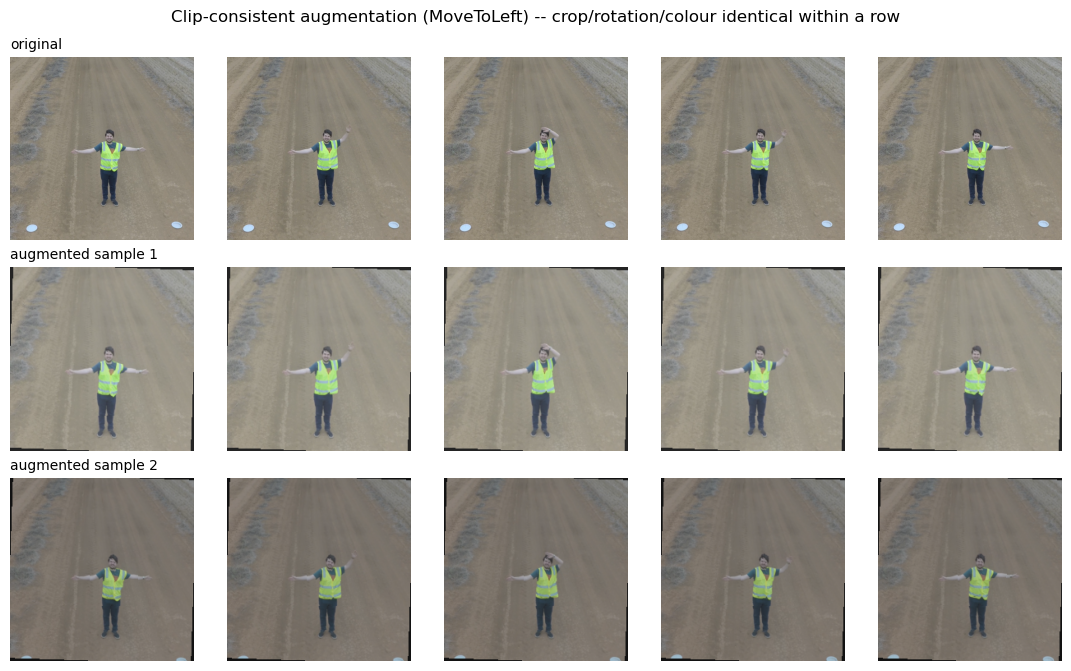

Each row must show ONE geometric/photometric transform applied to all five frames.
If the frames within a row were cropped differently, the temporal signal would be augmentation noise.


In [22]:
# Verification figure: the augmentation must be identical across the 5 frames
seed_everything()
row = df.sample(1, random_state=SEED).iloc[0]
raw = torch.stack([read_image(p, ImageReadMode.RGB) for p in row.frame_paths]).float() / 255.

fig, axes = plt.subplots(3, 5, figsize=(11, 6.8))
for c in range(5):
    axes[0, c].imshow(raw[c].permute(1, 2, 0).numpy()); axes[0, c].axis("off")
axes[0, 0].set_title("original", loc="left", fontsize=10)

for r, seed_off in enumerate([1, 2], start=1):
    random.seed(SEED + seed_off)
    aug = ClipAugment(IMG, train=True)(raw.clone())
    for c in range(5):
        axes[r, c].imshow(aug[c].permute(1, 2, 0).numpy()); axes[r, c].axis("off")
    axes[r, 0].set_title(f"augmented sample {r}", loc="left", fontsize=10)

fig.suptitle(f"Clip-consistent augmentation ({row.action}) -- crop/rotation/colour identical within a row")
plt.tight_layout(); plt.show()
print("Each row must show ONE geometric/photometric transform applied to all five frames.")
print("If the frames within a row were cropped differently, the temporal signal would be augmentation noise.")

## 4. Architecture

### 4.1 Choosing how to fuse five frames

Five candidate designs were considered. The relevant axes are whether the design can represent **frame order**, and what it costs per instance on the embedded board.

| Design | Order-aware? | Backbone passes / instance | Verdict |
|---|---|---|---|
| Middle frame only (3 ch) | no temporal info at all | 1× | Control. Establishes whether temporal information helps. |
| Per-frame backbone → **mean/max pool** | **No** — pooling is permutation-invariant | 5× | **Rejected on compute**, at 5× the budget. Note that §1 revised the usual argument against pooling: because these gestures are oscillatory rather than directional, the classes are separated by *which* poses appear rather than by their order, so pooling is not expected to fail badly on this data. Retained as a control that tests the order-independence claim directly. |
| Per-frame backbone → ordered concat | Yes | 5× | Strong, but violates the "one modest CNN" compute constraint. Kept as a control. |
| **Channel-stacked early fusion (15 ch)** | **Yes** | **1×** | **Selected.** |
| Frame differences (mid frame + 4 diffs) | Yes, explicitly | 1× | Evaluated as an alternative input encoding. |

**Why five frames are necessary at all.** §1 established this empirically rather than by assumption: `MoveUpward`, `MoveDownward`, `MoveToLeft` and `WaveOff` all begin and end in the same arms-out horizontal rest pose, which is precisely the pose `Hover` holds throughout. A single frame sampled at the wrong phase of the oscillation is therefore unidentifiable — four commands and a hold instruction collapse onto one image. Five frames guarantee that at least one distinctive extreme pose is observed regardless of where the segmenter cut. **The benefit is pose coverage across the oscillation cycle, not motion direction.**

**Early fusion by channel stacking** concatenates the 5 RGB frames into a single 15-channel tensor and lets the first convolution learn filters spanning all five poses at once. Because channel index encodes frame identity, the first layer can also represent order-sensitive patterns should any exist, so nothing is given up. This is the "early fusion" variant in Karpathy et al.'s study of fusion strategies for video CNNs (CVPR 2014), and critically it preserves all five poses at a **single** backbone pass — which is precisely what the compute constraint demands.

The **frame-difference** encoding (middle frame + 4 consecutive differences) hands the network motion explicitly rather than making it learn subtraction, in the spirit of the motion stream in Simonyan & Zisserman's two-stream networks (NeurIPS 2014) but without any external dataset or optical-flow dependency. On a dataset this small, removing work the network would otherwise have to learn is often decisive. §6 decides between the two on evidence rather than assertion.

### 4.2 Reconciling a 15-channel input with a 3-channel pretrained stem

Discarding ImageNet weights is not affordable here. Instead the stem convolution is **inflated**: the pretrained 3-channel kernel is replicated across the 5 frame-groups and divided by 5. Division matters — replication alone would multiply the stem's output magnitude by 5 and push every downstream BatchNorm far outside the statistics it was fitted with, wasting most of the pretrained value. This is the bootstrapping trick from Carreira & Zisserman's I3D (CVPR 2017), applied to the channel axis instead of the temporal axis. At initialisation the inflated stem computes the mean response over frames — a sensible, order-blind starting point that training then breaks symmetry from.

### 4.3 Backbone: MobileNetV3-Small

Chosen for the deployment constraint, not for accuracy. It is an inverted-residual, depthwise-separable architecture explicitly designed for constrained hardware (Howard et al., ICCV 2019), and at roughly 2.5M parameters it is also an appropriate capacity for a dataset of this size — a ResNet-50 would overfit a few hundred clips long before it converged. §12 measures the actual cost rather than asserting it.

### 4.4 The self-built segment

`ClassifierHead` is designed and trained from scratch, and is tuned in §7:

`BatchNorm1d → Dropout → Linear(feat→hidden) → Hardswish → Dropout → Linear(hidden→13)`

- **BatchNorm1d on the pooled features** stabilises the scale mismatch between a partially-inflated stem and a randomly initialised head during the warm-up phase.
- **Two dropout layers around a bottleneck** are the main regulariser. With few subjects, the dominant failure is memorising individuals; a heavy-dropout narrow bottleneck forces the head to rely on features shared across people.
- **Hardswish** matches the activation used throughout the MobileNetV3 trunk and is cheap on embedded hardware.

Its width and dropout rate are not asserted — they are selected by the sweep in §7.